# Data Collection

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import os
from pathlib import Path
import sys


PROJECT_ROOT = Path(os.getcwd()).parent 

sys.path.append(str(PROJECT_ROOT))

In [16]:
from src.data_process.merge_data import merge_data

DATA_DIR = PROJECT_ROOT / "data"
df_panel = merge_data(DATA_DIR)

Đang đọc và gộp dữ liệu tài chính từ 2008 đến 2024...
Đã merge thành công! Dữ liệu lưu tại: /Users/khanhba89/Documents/NEU/nckh_esg/data/interim/merged_raw_panel.csv


In [17]:
df_panel

,CERT,year,ZIP,STALP,NAME,CITY,ACTIVE,HEAT_DAYS,TMAX_AVG,HEAT_SHOCK_DUMMY,...,NIM,ROA,RBCT1J,NAASSET,P9ASSET,P3ASSET,NONII,NONIX,latitude,longitude
0,2413,2008,78130,TX,First State Bank,New Braunfels,0,29,26.818033,1,...,6478.000000,1.360593,21890.750000,1368.750000,166.250000,1756.500000,984.250000,5250.00,29.7229,-98.0742
1,2413,2009,78130,TX,First State Bank,New Braunfels,0,56,26.728493,1,...,6399.000000,1.206316,23525.750000,999.750000,43.000000,1758.750000,1051.000000,5275.00,29.7229,-98.0742
2,2413,2010,78130,TX,First State Bank,New Braunfels,0,12,25.279178,1,...,7242.000000,1.478374,25593.000000,1437.750000,22.500000,2015.000000,950.000000,5273.50,29.7229,-98.0742
3,2413,2011,78130,TX,First State Bank,New Braunfels,0,82,27.663014,1,...,7649.250000,1.593003,27621.000000,1907.250000,1004.000000,2880.250000,871.750000,5306.25,29.7229,-98.0742
4,2413,2012,78130,TX,First State Bank,New Braunfels,0,30,27.043716,1,...,5956.666667,1.308460,26611.333333,1011.666667,188.666667,2263.333333,590.333333,4530.00,29.7229,-98.0742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3083,90234,2020,1945,MA,Marblehead Bank,Marblehead,1,48,15.070219,1,...,4561.000000,0.223696,20843.750000,246.000000,485.250000,208.250000,894.250000,4985.75,42.4984,-70.8653
3084,90234,2021,1945,MA,Marblehead Bank,Marblehead,1,40,14.713425,1,...,4523.250000,0.238244,21467.500000,52.500000,98.000000,133.000000,850.250000,5022.50,42.4984,-70.8653
3085,90234,2022,1945,MA,Marblehead Bank,Marblehead,1,51,15.088493,1,...,4918.500000,0.112663,21957.750000,104.500000,0.000000,72.250000,641.750000,5100.50,42.4984,-70.8653
3086,90234,2023,1945,MA,Marblehead Bank,Marblehead,1,37,14.861918,1,...,6248.500000,0.592921,23636.750000,233.000000,37.500000,148.250000,568.000000,5511.75,42.4984,-70.8653


In [18]:
df_panel.shape

(3088, 23)

Sau khi gộp, data sẽ chứa các cột sau:

**Thông tin định danh**
'CERT', 'year', 'ZIP', 'STALP', 'NAME', 'CITY',

**Biến khí hậu (X)**
'HEAT_DAYS', 'TMAX_AVG', 'HEAT_SHOCK_DUMMY',

**Các biến tài chính thô cần để tính Z-score, NPL, SIZE, CAR**
'ASSET', 'EQTOT', 'LNLSNET', 'NIM', 'ROA', 'RBCT1J', 
'NAASSET', 'P9ASSET', 'P3ASSET', 'NONII', 'NONIX'

**Vị trí địa lí**
'latitude', 'longitude'

In [19]:
# Calculated features
from src.feature_engineering.target_variables import calculate_financial_features
df_calculated = calculate_financial_features(df_panel)
df_calculated

Đang tính toán các biến tài chính...
Đã tính toán xong các biến tài chính (SIZE, CAR, NPL_ratio, Z_score).


,CERT,year,ZIP,STALP,NAME,CITY,ACTIVE,HEAT_DAYS,TMAX_AVG,HEAT_SHOCK_DUMMY,...,AGE,SIZE,CAR_ratio,CAR,ROA_annual,NIM_annual,NPL_ratio,ROA_sd3,Z_score,ln_Zscore
0,2413,2008,78130,TX,First State Bank,New Braunfels,0,29,26.818033,1,...,0,19.277070,0.093787,9.378706,1.360593,6478.000000,0.651904,NaN,NaN,NaN
1,2413,2009,78130,TX,First State Bank,New Braunfels,0,56,26.728493,1,...,1,19.313387,0.097594,9.759381,1.206316,6399.000000,0.427054,NaN,NaN,NaN
2,2413,2010,78130,TX,First State Bank,New Braunfels,0,12,25.279178,1,...,2,19.398266,0.097370,9.737004,1.478374,7242.000000,0.549373,0.136437,82.201460,4.409173
3,2413,2011,78130,TX,First State Bank,New Braunfels,0,82,27.663014,1,...,3,19.413704,0.104107,10.410714,1.593003,7649.250000,1.078487,0.198613,60.437457,4.101609
4,2413,2012,78130,TX,First State Bank,New Braunfels,0,30,27.043716,1,...,4,19.387227,0.103702,10.370187,1.308460,5956.666667,0.456600,0.143164,81.574857,4.401521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3083,90234,2020,1945,MA,Marblehead Bank,Marblehead,1,48,15.070219,1,...,12,19.301794,0.079655,7.965537,0.223696,4561.000000,0.302973,0.063135,129.708336,4.865288
3084,90234,2021,1945,MA,Marblehead Bank,Marblehead,1,40,14.713425,1,...,13,19.469525,0.067451,6.745143,0.238244,4523.250000,0.052727,0.055040,126.875108,4.843203
3085,90234,2022,1945,MA,Marblehead Bank,Marblehead,1,51,15.088493,1,...,14,19.477697,0.068073,6.807348,0.112663,4918.500000,0.036313,0.068691,100.740181,4.612545
3086,90234,2023,1945,MA,Marblehead Bank,Marblehead,1,37,14.861918,1,...,15,19.386354,0.083577,8.357716,0.592921,6248.500000,0.102987,0.249070,35.936151,3.581744


In [20]:
# Winsorize 1%-99%
vars_to_winsorize = ['SIZE', 'ROA_annual', 'CAR', 'NIM', 'NPL_ratio', 'Z_score']
from src.preprocessing.winsorize import apply_winsorization

df_winsorized = apply_winsorization(
    df=df_calculated,
    columns_to_winsorize=vars_to_winsorize,
    limits=[0.01, 0.01]
)

df_winsorized

Đã xử lý Winsorize thành công cho cột: SIZE
Đã xử lý Winsorize thành công cho cột: ROA_annual
Đã xử lý Winsorize thành công cho cột: CAR
Đã xử lý Winsorize thành công cho cột: NIM
Đã xử lý Winsorize thành công cho cột: NPL_ratio
Đã xử lý Winsorize thành công cho cột: Z_score


,CERT,year,ZIP,STALP,NAME,CITY,ACTIVE,HEAT_DAYS,TMAX_AVG,HEAT_SHOCK_DUMMY,...,AGE,SIZE,CAR_ratio,CAR,ROA_annual,NIM_annual,NPL_ratio,ROA_sd3,Z_score,ln_Zscore
0,2413,2008,78130,TX,First State Bank,New Braunfels,0,29,26.818033,1,...,0,19.277070,0.093787,9.378706,1.360593,6478.000000,0.651904,NaN,NaN,NaN
1,2413,2009,78130,TX,First State Bank,New Braunfels,0,56,26.728493,1,...,1,19.313387,0.097594,9.759381,1.206316,6399.000000,0.427054,NaN,NaN,NaN
2,2413,2010,78130,TX,First State Bank,New Braunfels,0,12,25.279178,1,...,2,19.398266,0.097370,9.737004,1.478374,7242.000000,0.549373,0.136437,82.201460,4.409173
3,2413,2011,78130,TX,First State Bank,New Braunfels,0,82,27.663014,1,...,3,19.413704,0.104107,10.410714,1.593003,7649.250000,1.078487,0.198613,60.437457,4.101609
4,2413,2012,78130,TX,First State Bank,New Braunfels,0,30,27.043716,1,...,4,19.387227,0.103702,10.370187,1.308460,5956.666667,0.456600,0.143164,81.574857,4.401521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3083,90234,2020,1945,MA,Marblehead Bank,Marblehead,1,48,15.070219,1,...,12,19.301794,0.079655,7.965537,0.223696,4561.000000,0.302973,0.063135,129.708336,4.865288
3084,90234,2021,1945,MA,Marblehead Bank,Marblehead,1,40,14.713425,1,...,13,19.469525,0.067451,6.745143,0.238244,4523.250000,0.052727,0.055040,126.875108,4.843203
3085,90234,2022,1945,MA,Marblehead Bank,Marblehead,1,51,15.088493,1,...,14,19.477697,0.068073,6.807348,0.112663,4918.500000,0.036313,0.068691,100.740181,4.612545
3086,90234,2023,1945,MA,Marblehead Bank,Marblehead,1,37,14.861918,1,...,15,19.386354,0.083577,8.357716,0.592921,6248.500000,0.102987,0.249070,35.936151,3.581744


In [21]:
# Calculated Lag Features
from src.feature_engineering.lag_features import generate_climate_lag_features

df_final = generate_climate_lag_features(df_winsorized)
df_final

Đã tạo thành công các biến trễ (Lag 1 & Lag 2) cho dữ liệu khí hậu.


,CERT,year,ZIP,STALP,NAME,CITY,ACTIVE,HEAT_DAYS,TMAX_AVG,HEAT_SHOCK_DUMMY,...,CAR,ROA_annual,NIM_annual,NPL_ratio,ROA_sd3,Z_score,ln_Zscore,HEAT_DAYS_LAG1,HEAT_DAYS_LAG2,TMAX_AVG_LAG1
0,2413,2008,78130,TX,First State Bank,New Braunfels,0,29,26.818033,1,...,9.378706,1.360593,6478.000000,0.651904,NaN,NaN,NaN,NaN,NaN,NaN
1,2413,2009,78130,TX,First State Bank,New Braunfels,0,56,26.728493,1,...,9.759381,1.206316,6399.000000,0.427054,NaN,NaN,NaN,29.0,NaN,26.818033
2,2413,2010,78130,TX,First State Bank,New Braunfels,0,12,25.279178,1,...,9.737004,1.478374,7242.000000,0.549373,0.136437,82.201460,4.409173,56.0,29.0,26.728493
3,2413,2011,78130,TX,First State Bank,New Braunfels,0,82,27.663014,1,...,10.410714,1.593003,7649.250000,1.078487,0.198613,60.437457,4.101609,12.0,56.0,25.279178
4,2413,2012,78130,TX,First State Bank,New Braunfels,0,30,27.043716,1,...,10.370187,1.308460,5956.666667,0.456600,0.143164,81.574857,4.401521,82.0,12.0,27.663014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3083,90234,2020,1945,MA,Marblehead Bank,Marblehead,1,48,15.070219,1,...,7.965537,0.223696,4561.000000,0.302973,0.063135,129.708336,4.865288,41.0,45.0,13.743836
3084,90234,2021,1945,MA,Marblehead Bank,Marblehead,1,40,14.713425,1,...,6.745143,0.238244,4523.250000,0.052727,0.055040,126.875108,4.843203,48.0,41.0,15.070219
3085,90234,2022,1945,MA,Marblehead Bank,Marblehead,1,51,15.088493,1,...,6.807348,0.112663,4918.500000,0.036313,0.068691,100.740181,4.612545,40.0,48.0,14.713425
3086,90234,2023,1945,MA,Marblehead Bank,Marblehead,1,37,14.861918,1,...,8.357716,0.592921,6248.500000,0.102987,0.249070,35.936151,3.581744,51.0,40.0,15.088493


In [22]:
df_final.columns

Index(['CERT', 'year', 'ZIP', 'STALP', 'NAME', 'CITY', 'ACTIVE', 'HEAT_DAYS',
       'TMAX_AVG', 'HEAT_SHOCK_DUMMY', 'ASSET', 'EQTOT', 'LNLSNET', 'NIM',
       'ROA', 'RBCT1J', 'NAASSET', 'P9ASSET', 'P3ASSET', 'NONII', 'NONIX',
       'latitude', 'longitude', 'FIRST_YEAR', 'AGE', 'SIZE', 'CAR_ratio',
       'CAR', 'ROA_annual', 'NIM_annual', 'NPL_ratio', 'ROA_sd3', 'Z_score',
       'ln_Zscore', 'HEAT_DAYS_LAG1', 'HEAT_DAYS_LAG2', 'TMAX_AVG_LAG1'],
      dtype='str')

In [23]:
df_final = df_final.dropna(inplace=False)
df_final

,CERT,year,ZIP,STALP,NAME,CITY,ACTIVE,HEAT_DAYS,TMAX_AVG,HEAT_SHOCK_DUMMY,...,CAR,ROA_annual,NIM_annual,NPL_ratio,ROA_sd3,Z_score,ln_Zscore,HEAT_DAYS_LAG1,HEAT_DAYS_LAG2,TMAX_AVG_LAG1
2,2413,2010,78130,TX,First State Bank,New Braunfels,0,12,25.279178,1,...,9.737004,1.478374,7242.000000,0.549373,0.136437,82.201460,4.409173,56.0,29.0,26.728493
3,2413,2011,78130,TX,First State Bank,New Braunfels,0,82,27.663014,1,...,10.410714,1.593003,7649.250000,1.078487,0.198613,60.437457,4.101609,12.0,56.0,25.279178
4,2413,2012,78130,TX,First State Bank,New Braunfels,0,30,27.043716,1,...,10.370187,1.308460,5956.666667,0.456600,0.143164,81.574857,4.401521,82.0,12.0,27.663014
7,2429,2010,23487,VA,Farmers Bank,Windsor,0,64,20.566849,1,...,8.036014,-1.570221,8395.500000,2.315535,1.160062,5.661970,1.718051,15.0,32.0,19.801918
8,2429,2011,23487,VA,Farmers Bank,Windsor,0,48,21.340548,1,...,8.452338,0.454322,8196.250000,1.787784,1.167621,7.628034,2.031830,64.0,15.0,20.566849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3083,90234,2020,1945,MA,Marblehead Bank,Marblehead,1,48,15.070219,1,...,7.965537,0.223696,4561.000000,0.302973,0.063135,129.708336,4.865288,41.0,45.0,13.743836
3084,90234,2021,1945,MA,Marblehead Bank,Marblehead,1,40,14.713425,1,...,6.745143,0.238244,4523.250000,0.052727,0.055040,126.875108,4.843203,48.0,41.0,15.070219
3085,90234,2022,1945,MA,Marblehead Bank,Marblehead,1,51,15.088493,1,...,6.807348,0.112663,4918.500000,0.036313,0.068691,100.740181,4.612545,40.0,48.0,14.713425
3086,90234,2023,1945,MA,Marblehead Bank,Marblehead,1,37,14.861918,1,...,8.357716,0.592921,6248.500000,0.102987,0.249070,35.936151,3.581744,51.0,40.0,15.088493


**Sau khi tiền xử lý dữ liêu, ta sẽ có một bảng với 2654 dòng, 13 features.**
#### Trong đó ta sẽ sử dụng các features sau làm input cho model:
##### Biến phụ thuộc Y
- `NPL_ratio` (Tỷ lệ nợ xấu - %)
- `Z_score` (Chỉ số an toàn): Đo lường khoảng cách đến khả năng vỡ nợ
- `ln_Zscore`: Logarit tự nhiên của Z-score để phân phối biến tiệm cận phân phối chuẩn.
##### Biến độc lập X
- `HEAT_DAYS` (Số ngày sốc nhiệt - tương ứng với `HEAT_SHOCK_DAYS` trong lý thuyết): Số ngày trong năm $t$ có nhiệt độ tối đa vượt ngưỡng phân vị thứ 90 (P90) lịch sử của mã ZIP đặt trụ sở ngân hàng.
- `TMAX_AVG` (Nhiệt độ tối đa trung bình - tương ứng với `HEAT_SHOCK_INTENSITY` trong lý thuyết): Nhiệt độ tối đa trung bình hàng ngày trong năm $t$ (°C).
- **Biến trễ (Lagged Climate Variables)**: `HEAT_DAYS_LAG1`, `HEAT_DAYS_LAG2`, `TMAX_AVG_LAG1`
##### Biến điều phối
- `longitude`, `latitude`: Toạ độ vị trí của ngân hàng -> Kiểm tra xem vị trí có liên quan gì đến việc tác động của sốc nhiệt lên sức khoẻ của ngân hàng
- `ACTIVE`: Ngân hàng còn hoạt động hay không? Giả định là các ngân hàng có 0 là các ngân hàng ngừng hoạt động do phá sản (Tạm thời bỏ)

In [24]:
# ==========================================
# 1. CHUẨN BỊ FEATURES VÀ TARGET (100% Data)
# ==========================================
target_1 = 'NPL_ratio'  # Biến mục tiêu chính: Tỷ lệ nợ xấu (NPL ratio)

features_1 = [
    # Khí hậu
    'HEAT_DAYS', 'HEAT_DAYS_LAG1', 'HEAT_DAYS_LAG2',
    'TMAX_AVG', 'TMAX_AVG_LAG1',
    # Địa lý
    'latitude', 'longitude',
    # Nội tại ngân hàng (Kiểm soát)
    'SIZE', 'CAR_ratio', 'ROA_annual', 'NIM_annual', 'ROA_sd3', 'AGE'
]

# Sử dụng toàn bộ dữ liệu cho ma trận X và target y
X = df_final[features_1]
y = df_final[target_1]

X


,HEAT_DAYS,HEAT_DAYS_LAG1,HEAT_DAYS_LAG2,TMAX_AVG,TMAX_AVG_LAG1,latitude,longitude,SIZE,CAR_ratio,ROA_annual,NIM_annual,ROA_sd3,AGE
2,12,56.0,29.0,25.279178,26.728493,29.7229,-98.0742,19.398266,0.097370,1.478374,7242.000000,0.136437,2
3,82,12.0,56.0,27.663014,25.279178,29.7229,-98.0742,19.413704,0.104107,1.593003,7649.250000,0.198613,3
4,30,82.0,12.0,27.043716,27.663014,29.7229,-98.0742,19.387227,0.103702,1.308460,5956.666667,0.143164,4
7,64,15.0,32.0,20.566849,19.801918,36.8369,-76.7324,19.918292,0.080360,-1.570221,8395.500000,1.160062,2
8,48,64.0,15.0,21.340548,20.566849,36.8369,-76.7324,19.909632,0.084523,0.454322,8196.250000,1.167621,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3083,48,41.0,45.0,15.070219,13.743836,42.4984,-70.8653,19.301794,0.079655,0.223696,4561.000000,0.063135,12
3084,40,48.0,41.0,14.713425,15.070219,42.4984,-70.8653,19.469525,0.067451,0.238244,4523.250000,0.055040,13
3085,51,40.0,48.0,15.088493,14.713425,42.4984,-70.8653,19.477697,0.068073,0.112663,4918.500000,0.068691,14
3086,37,51.0,40.0,14.861918,15.088493,42.4984,-70.8653,19.386354,0.083577,0.592921,6248.500000,0.249070,15


In [25]:
y.describe()

count    2654.000000
mean        0.677547
std         0.856867
min         0.000000
25%         0.119323
50%         0.398613
75%         0.914349
max         4.890430
Name: NPL_ratio, dtype: float64

--- ĐANG HUẤN LUYỆN MÔ HÌNH TRÊN TOÀN BỘ BỘ DỮ LIỆU ---
R2 Score trên toàn bộ dữ liệu: 0.5117
RMSE trên toàn bộ dữ liệu    : 0.5986

Đang tính toán SHAP values từ mô hình tổng để tìm ngưỡng...
-> Đang vẽ đồ thị tìm ngưỡng cho HEAT_DAYS...


<Figure size 1000x600 with 0 Axes>

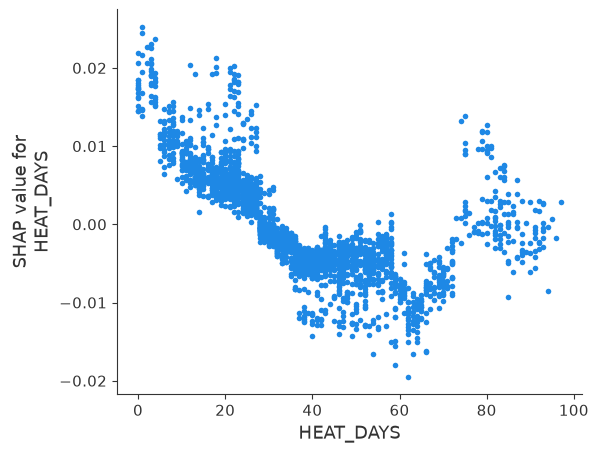

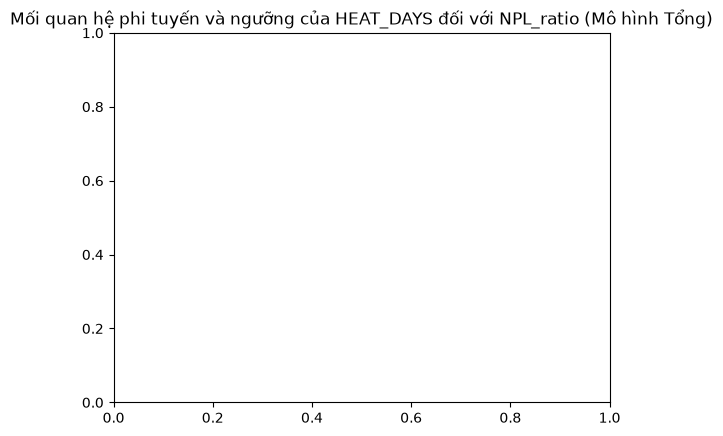

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import shap

# ==========================================
# 2. KHỞI TẠO MÔ HÌNH XGBOOST 
# ==========================================
# Cấu hình siêu mịn để vẽ đồ thị SHAP không bị nhiễu răng cưa
model = xgb.XGBRegressor(
    max_depth=3,            # Độ sâu từ 2 đến 3 giúp gom các ngưỡng lớn tổng quát
    learning_rate=0.01,     # Tốc độ học nhỏ để cây bao phủ không bị gắt
    n_estimators=800,       # Số cây vừa đủ để mô hình hội tụ ổn định trên toàn bộ data
    min_child_weight=40,    # Đảm bảo mỗi vùng cắt có ít nhất 40 quan sát
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42
)

# ==========================================
# 3. HUẤN LUYỆN TRỰC TIẾP TRÊN TOÀN BỘ DATA
# ==========================================
print("--- ĐANG HUẤN LUYỆN MÔ HÌNH TRÊN TOÀN BỘ BỘ DỮ LIỆU ---")
model.fit(X, y)

# Đánh giá độ khớp (In-sample goodness of fit)
preds = model.predict(X)
print(f"R2 Score trên toàn bộ dữ liệu: {r2_score(y, preds):.4f}")
print(f"RMSE trên toàn bộ dữ liệu    : {np.sqrt(mean_squared_error(y, preds)):.4f}")

# ==========================================
# 4. TRÍCH XUẤT NGƯỠNG PHI TUYẾN BẰNG SHAP
# ==========================================
print("\nĐang tính toán SHAP values từ mô hình tổng để tìm ngưỡng...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

# Đồ thị 1: Tìm ngưỡng cho số ngày sốc nhiệt (HEAT_DAYS)
print("-> Đang vẽ đồ thị tìm ngưỡng cho HEAT_DAYS...")
plt.figure(figsize=(10, 6))
shap.dependence_plot("HEAT_DAYS", shap_values.values, X, interaction_index=None)
plt.title(f"Mối quan hệ phi tuyến và ngưỡng của HEAT_DAYS đối với {target_1} (Mô hình Tổng)", fontsize=12)
plt.show()

# # Đồ thị 2: Tìm ngưỡng cho nhiệt độ tối đa trung bình (TMAX_AVG)
print("-> Đang vẽ đồ thị tìm ngưỡng cho TMAX_AVG...")
plt.figure(figsize=(10, 6))
shap.dependence_plot("TMAX_AVG", shap_values.values, X, interaction_index=None)
plt.title(f"Mối quan hệ phi tuyến và ngưỡng của TMAX_AVG đối với {target_1} (Mô hình Tổng)", fontsize=12)
plt.show()